In [24]:
# import libraries
import numpy as np
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt

# Keras 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Conv1D, GlobalMaxPooling1D, SeparableConv1D, Dense, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load dataset
data = pd.read_csv('dataset.csv')

In [3]:
dataset = data.copy()

In [4]:
dataset.head()

,id,pub_title,dataset_label,full_text
0,d0fa7568-7d8e-4db9-870f-f9c6f668c17b,The Impact of Dual Enrollment on College Degre...,national education longitudinal study,what is this study about this study used data ...
1,2f26f645-3dec-485d-b68d-f013c9e05e60,Educational Attainment of High School Dropouts...,national education longitudinal study,november 2004 dropping out of high school is n...
2,c5d5cd2c-59de-4f29-bbb1-6a88c7b52f29,Differences in Outcomes for Female and Male St...,national education longitudinal study,differences in outcomes for female and male st...
3,5c9a3bc9-41ba-4574-ad71-e25c1442c8af,Stepping Stone and Option Value in a Model of ...,national education longitudinal study,abstract federal reserve bank of richmond s1 a...
4,c754dec7-c5a3-4337-9892-c02158475064,"Parental Effort, School Resources, and Student...",national education longitudinal study,abstract this article investigates an importan...


In [5]:
dataset['dataset_label'].value_counts()

dataset_label
adni                                                                    3673
alzheimers disease neuroimaging initiative adni                         2400
trends in international mathematics and science study                   1163
baltimore longitudinal study of aging                                   1156
early childhood longitudinal study                                      1011
                                                                        ... 
national oceanic and atmospheric administration ccap                       1
national oceanic and atmospheric administration world ocean database       1
noaa international best track archive for climate stewardship              1
aging integrated database agid                                             1
cas covid19 antiviral candidate compounds data                             1
Name: count, Length: 130, dtype: int64

In [6]:
df = dataset.groupby('dataset_label').filter(lambda x: len(x) >= 4)

In [7]:
# Split into Train 80%, Validation 10%, Test 10%
X = df['full_text']
y = df['dataset_label']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, shuffle=True)

In [8]:
# Tokenization 
num_words = 10000
tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

In [9]:
# Convert texts to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

In [10]:
# Padding sequences
max_len = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

In [11]:
# Encoding categorical labels
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

In [12]:
# Convert the integer-encoded labels into a binary class matrix
num_classes = len(le.classes_)

y_train_cat = to_categorical(y_train_enc, num_classes=num_classes)
y_val_cat   = to_categorical(y_val_enc,   num_classes=num_classes)
y_test_cat  = to_categorical(y_test_enc,  num_classes=num_classes)

In [13]:
# GRU model
gru_model = Sequential(name="gru_model")
gru_model.add(Embedding(input_dim=num_words, output_dim=64))
gru_model.add(GRU(units=64, dropout=0.3, recurrent_dropout=0))
gru_model.add(Dense(y_train_cat.shape[1], activation='softmax'))

optimizer = Adam(learning_rate=0.0005) 

gru_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

2026-02-06 13:04:27.895455: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-02-06 13:04:27.895783: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-02-06 13:04:27.895804: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-02-06 13:04:27.896547: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-02-06 13:04:27.897241: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [ ]:
# Train the model
callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=3)

history = gru_model.fit(
    X_train_pad, y_train_cat,
    batch_size=16,  
    epochs=10, 
    validation_data=(X_val_pad, y_val_cat),
    verbose=1,
    callbacks=[callback]
)

In [ ]:
# Plot GRU model training and validation accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [ ]:
# Evaluate the model on the test set
loss, accuracy = gru_model.evaluate(X_test_pad, y_test_cat, batch_size=32)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

In [14]:
# Bidirectional LSTM model
bilstm_model = Sequential(name='bilstm_model')
bilstm_model.add(Embedding(input_dim=num_words, output_dim=64))
bilstm_model.add(Bidirectional(LSTM(units=64, dropout=0.3)))
bilstm_model.add(Dense(y_train_cat.shape[1], activation='softmax'))
bilstm_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [15]:
# Train the model

history_bilstm = bilstm_model.fit(
    X_train_pad, y_train_cat,
    batch_size=16,  
    epochs=15, 
    validation_data=(X_val_pad, y_val_cat),
    verbose=1
)

Epoch 1/15


2026-02-06 13:04:30.248216: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


980/980 ━━━━━━━━━━━━━━━━━━━━ 94s 92ms/step - accuracy: 0.1907 - loss: 3.3816 - val_accuracy: 0.2638 - val_loss: 2.7101
Epoch 2/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.2557 - loss: 2.6369 - val_accuracy: 0.2791 - val_loss: 2.4216
Epoch 3/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.2902 - loss: 2.3501 - val_accuracy: 0.3408 - val_loss: 2.2273
Epoch 4/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.3468 - loss: 2.1432 - val_accuracy: 0.3653 - val_loss: 2.0580
Epoch 5/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.3518 - loss: 2.0833 - val_accuracy: 0.3735 - val_loss: 1.9361
Epoch 6/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 90s 92ms/step - accuracy: 0.4035 - loss: 1.8326 - val_accuracy: 0.4163 - val_loss: 1.7952
Epoch 7/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 92s 94ms/step - accuracy: 0.4367 - loss: 1.6794 - val_accuracy: 0.4337 - val_loss: 1.7271
Epoch 8/15
980/980 ━━━━━━━━━━━━━━━━━━━━ 91s 92ms/step - accuracy: 0.4711 - loss: 1.5714 - val_accurac

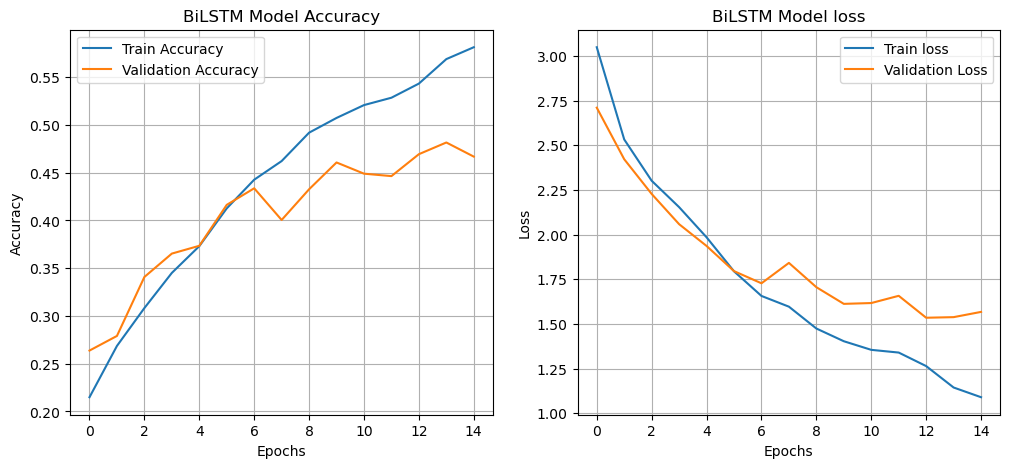

In [16]:
# Plot BiLSTM model training and validation accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_bilstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('BiLSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_bilstm.history['loss'], label='Train loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('BiLSTM Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [18]:
# Evaluate the model on the test set
loss_bi, accuracy_bi = bilstm_model.evaluate(X_test_pad, y_test_cat, batch_size=32)
print(f"Test Loss: {loss_bi:.4f}")
print(f"Test Accuracy: {accuracy_bi:.4f}")

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.4838 - loss: 1.4857
Test Loss: 1.5235
Test Accuracy: 0.4727


In [25]:
# Sep-CNN Model

embedding_dim = 50 

sepcnn_model = Sequential(name="sepcnn_model")
sepcnn_model.add(Embedding(input_dim=num_words, output_dim=embedding_dim))
sepcnn_model.add(SeparableConv1D(filters=32, kernel_size=3, activation='relu', strides=1, padding='same'))
sepcnn_model.add(GlobalMaxPooling1D())
sepcnn_model.add(Dropout(0.3))
sepcnn_model.add(Dense(64, activation='relu'))
sepcnn_model.add(Dropout(0.3))
sepcnn_model.add(Dense(units=num_classes, activation='softmax'))

# Compile the model
sepcnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
# Train the model

history_sepcnn = sepcnn_model.fit(
    X_train_pad, y_train_cat,
    batch_size=16,  
    epochs=10, 
    validation_data=(X_val_pad, y_val_cat),
    verbose=1
)

Epoch 1/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - accuracy: 0.1889 - loss: 3.3255 - val_accuracy: 0.3434 - val_loss: 2.2737
Epoch 2/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 23s 23ms/step - accuracy: 0.3327 - loss: 2.2451 - val_accuracy: 0.4643 - val_loss: 1.7208
Epoch 3/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.4243 - loss: 1.8335 - val_accuracy: 0.5112 - val_loss: 1.5153
Epoch 4/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.4596 - loss: 1.6333 - val_accuracy: 0.5163 - val_loss: 1.4120
Epoch 5/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.4859 - loss: 1.5104 - val_accuracy: 0.5245 - val_loss: 1.3627
Epoch 6/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.5070 - loss: 1.4274 - val_accuracy: 0.5235 - val_loss: 1.3339
Epoch 7/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.5313 - loss: 1.3443 - val_accuracy: 0.5352 - val_loss: 1.3088
Epoch 8/10
980/980 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.5291 - loss: 1.3013 - 

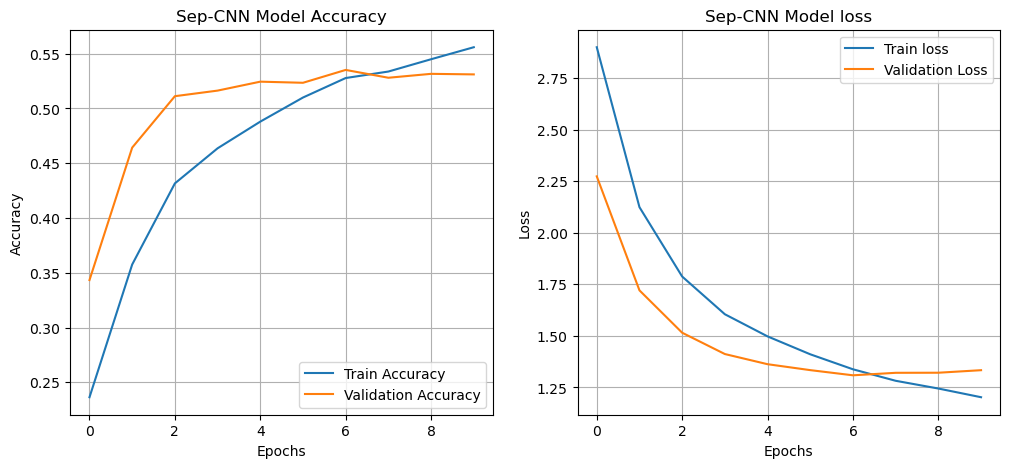

In [27]:
# Plot Sep-CNN model training and validation accuracy
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_sepcnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_sepcnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Sep-CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_sepcnn.history['loss'], label='Train loss')
plt.plot(history_sepcnn.history['val_loss'], label='Validation Loss')
plt.title('Sep-CNN Model loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

In [28]:
# Evaluate the model on the test set
loss_sepcnn, accuracy_sepcnn = sepcnn_model.evaluate(X_test_pad, y_test_cat, batch_size=32)
print(f"Test Loss: {loss_sepcnn:.4f}")
print(f"Test Accuracy: {accuracy_sepcnn:.4f}")

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5515 - loss: 1.2656
Test Loss: 1.2981
Test Accuracy: 0.5426
